In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


In [2]:
p1g =pd.read_csv(Path(os.getcwd()).parent / 'datos' / 'brutos' / 'Planta1_Generacion.csv')
p2g =pd.read_csv(Path(os.getcwd()).parent / 'datos' / 'brutos' / 'Planta2_Generacion.csv')
p1s =pd.read_csv(Path(os.getcwd()).parent / 'datos' / 'brutos' / 'Planta1_Sensores.csv')
p2s =pd.read_csv(Path(os.getcwd()).parent / 'datos' / 'brutos' / 'Planta2_Sensores.csv')

# Agrupar los DataFrames para las verificaciones posteriores
datasets = {
    'Planta1_Generacion': p1g,
    'Planta2_Generacion': p2g,
    'Planta1_Sensores': p1s,
    'Planta2_Sensores': p2s,
}


In [5]:
p1g['fecha_hora'] = pd.to_datetime(p1g['fecha_hora'], dayfirst=True, format='%d-%m-%Y %H:%M')

In [7]:
p1g['id_planta'] = p1g['id_planta'].replace(4135001,'p1')

In [12]:
p2g['fecha_hora'] = pd.to_datetime(p2g['fecha_hora'])

In [13]:
p2g['id_planta'] = p2g['id_planta'].replace(4136001,'p2')

In [15]:
# Dividir por 10 la potencia_dc_kw de la planta 1
p1g['potencia_dc_kw'] = p1g['potencia_dc_kw'] / 10

In [19]:
p1s['fecha_hora'] = pd.to_datetime(p1s['fecha_hora'])

In [20]:
p1s['id_planta'] = p1s['id_planta'].replace(4135001,'p1')

In [22]:
p1s['id_sensor_meteorologico'] = p1s['id_sensor_meteorologico'].replace('HmiyD2TTLFNqkNe','sensor_p1')

In [26]:
p2s['fecha_hora'] = pd.to_datetime(p2s['fecha_hora'])

In [27]:
p2s['id_planta'] = p2s['id_planta'].replace(4136001,'p2')

In [29]:
p2s['id_sensor_meteorologico'] = p2s['id_sensor_meteorologico'].replace('iq8k7ZNt4Mwm3w0','sensor_p2')

In [32]:
# Agrupar los dataframes importados para recorrerlos con el mismo c?digo
datasets = {
    'Planta1_Generacion': p1g,
    'Planta2_Generacion': p2g,
    'Planta1_Sensores': p1s,
    'Planta2_Sensores': p2s,
}

# Extraer fechas únicas (sin hora) de cada dataset para verificar cobertura
print("=== VERIFICACIÓN DE DÍAS ÚNICOS ===")

# Extraer solo la fecha (sin hora) de cada dataset
fechas_p1g = set(p1g['fecha_hora'].dt.date)
fechas_p2g = set(p2g['fecha_hora'].dt.date)
fechas_p1s = set(p1s['fecha_hora'].dt.date)
fechas_p2s = set(p2s['fecha_hora'].dt.date)

print(f"Días únicos en Planta1_Generacion: {len(fechas_p1g)}")
print(f"Días únicos en Planta2_Generacion: {len(fechas_p2g)}")
print(f"Días únicos en Planta1_Sensores: {len(fechas_p1s)}")
print(f"Días únicos en Planta2_Sensores: {len(fechas_p2s)}")
print()

# Verificar si todos tienen exactamente los mismos días
if fechas_p1g == fechas_p2g == fechas_p1s == fechas_p2s:
    print("✅ Todos los datasets tienen exactamente los mismos días")
else:
    print("❌ Los datasets NO tienen los mismos días")
    
    # Encontrar diferencias
    todas_fechas = fechas_p1g | fechas_p2g | fechas_p1s | fechas_p2s
    
    print("\nFechas faltantes por dataset:")
    if fechas_p1g != todas_fechas:
        faltantes = todas_fechas - fechas_p1g
        print(f"  Planta1_Generacion: {len(faltantes)} días faltantes")
    if fechas_p2g != todas_fechas:
        faltantes = todas_fechas - fechas_p2g
        print(f"  Planta2_Generacion: {len(faltantes)} días faltantes")
    if fechas_p1s != todas_fechas:
        faltantes = todas_fechas - fechas_p1s
        print(f"  Planta1_Sensores: {len(faltantes)} días faltantes")
    if fechas_p2s != todas_fechas:
        faltantes = todas_fechas - fechas_p2s
        print(f"  Planta2_Sensores: {len(faltantes)} días faltantes")

=== VERIFICACIÓN DE DÍAS ÚNICOS ===


Días únicos en Planta1_Generacion: 34
Días únicos en Planta2_Generacion: 34
Días únicos en Planta1_Sensores: 34
Días únicos en Planta2_Sensores: 34

✅ Todos los datasets tienen exactamente los mismos días


In [33]:
# Verificar continuidad de días (que no falte ningún día intermedio)
print("=== VERIFICACIÓN DE CONTINUIDAD DE DÍAS ===")

# Obtener fecha mínima y máxima global
fecha_min_global = min(p1g['fecha_hora'].min(), p2g['fecha_hora'].min(), 
                       p1s['fecha_hora'].min(), p2s['fecha_hora'].min()).date()
fecha_max_global = max(p1g['fecha_hora'].max(), p2g['fecha_hora'].max(), 
                       p1s['fecha_hora'].max(), p2s['fecha_hora'].max()).date()

print(f"Período completo: {fecha_min_global} a {fecha_max_global}")

# Generar rango completo de fechas esperadas
fechas_esperadas = set()
fecha_actual = fecha_min_global
while fecha_actual <= fecha_max_global:
    fechas_esperadas.add(fecha_actual)
    fecha_actual += pd.Timedelta(days=1)

print(f"Días esperados en el período: {len(fechas_esperadas)}")

# Verificar cada dataset
for nombre, df in datasets.items():
    fechas_dataset = set(df['fecha_hora'].dt.date)
    dias_faltantes = fechas_esperadas - fechas_dataset
    
    if len(dias_faltantes) == 0:
        print(f"✅ {nombre}: Completo, sin días faltantes")
    else:
        print(f"❌ {nombre}: Faltan {len(dias_faltantes)} días")
        if len(dias_faltantes) <= 10:  # Mostrar solo si son pocos
            print(f"   Días faltantes: {sorted(list(dias_faltantes))}")
        else:
            print(f"   Primeros días faltantes: {sorted(list(dias_faltantes))[:5]}...")

=== VERIFICACIÓN DE CONTINUIDAD DE DÍAS ===
Período completo: 2020-05-15 a 2020-06-17
Días esperados en el período: 34
✅ Planta1_Generacion: Completo, sin días faltantes
✅ Planta2_Generacion: Completo, sin días faltantes
✅ Planta1_Sensores: Completo, sin días faltantes
✅ Planta2_Sensores: Completo, sin días faltantes


In [34]:
# Resumen final
print("=== RESUMEN FINAL ===")

# Verificar si todos los datasets son idénticos en términos de cobertura de fechas
todos_iguales = fechas_p1g == fechas_p2g == fechas_p1s == fechas_p2s
todos_completos = all(len(fechas_esperadas - set(df['fecha_hora'].dt.date)) == 0 
                     for df in datasets.values())

if todos_iguales and todos_completos:
    print("✅ PERFECTO: Todos los datasets tienen exactamente los mismos días")
    print("✅ PERFECTO: No falta ningún día intermedio en ningún dataset")
    print(f"   Período: {fecha_min_global} a {fecha_max_global}")
    print(f"   Total días: {len(fechas_esperadas)}")
elif todos_iguales:
    print("✅ Todos los datasets tienen los mismos días")
    print("❌ Pero faltan algunos días intermedios en todos los datasets")
elif todos_completos:
    print("✅ Todos los datasets están completos (sin días faltantes)")
    print("❌ Pero no todos los datasets cubren exactamente el mismo período")
else:
    print("❌ Los datasets tienen diferentes coberturas de fechas")
    print("❌ Y algunos tienen días faltantes")

print(f"\nPeriodo analizado: {(fecha_max_global - fecha_min_global).days + 1} días")

=== RESUMEN FINAL ===
✅ PERFECTO: Todos los datasets tienen exactamente los mismos días
✅ PERFECTO: No falta ningún día intermedio en ningún dataset
   Período: 2020-05-15 a 2020-06-17
   Total días: 34

Periodo analizado: 34 días


In [35]:
# VERIFICACIÓN DE COMPLETITUD DE TRAMOS HORARIOS (15 minutos)
print("=== ANÁLISIS DE TRAMOS HORARIOS DE 15 MINUTOS ===")

# Función para generar todos los tramos de 15 minutos esperados para un día
def generar_tramos_15min_dia():
    """Genera todos los 96 tramos de 15 minutos de un día (00:00 a 23:45)"""
    tramos = []
    for hora in range(24):
        for minuto in [0, 15, 30, 45]:
            tramos.append(f"{hora:02d}:{minuto:02d}")
    return tramos

tramos_esperados_dia = generar_tramos_15min_dia()
print(f"Tramos esperados por día: {len(tramos_esperados_dia)}")
print(f"Primeros 8 tramos: {tramos_esperados_dia[:8]}")
print(f"Últimos 8 tramos: {tramos_esperados_dia[-8:]}")
print()

=== ANÁLISIS DE TRAMOS HORARIOS DE 15 MINUTOS ===
Tramos esperados por día: 96
Primeros 8 tramos: ['00:00', '00:15', '00:30', '00:45', '01:00', '01:15', '01:30', '01:45']
Últimos 8 tramos: ['22:00', '22:15', '22:30', '22:45', '23:00', '23:15', '23:30', '23:45']



In [36]:
# Función para analizar completitud de tramos horarios por dataset
def analizar_completitud_tramos(df, nombre_dataset):
    """Analiza la completitud de tramos de 15 minutos en un dataset"""
    print(f"\n--- {nombre_dataset} ---")
    
    # Crear columnas auxiliares
    df_temp = df.copy()
    df_temp['fecha'] = df_temp['fecha_hora'].dt.date
    df_temp['hora_minuto'] = df_temp['fecha_hora'].dt.strftime('%H:%M')
    
    # Obtener fechas únicas
    fechas_unicas = sorted(df_temp['fecha'].unique())
    print(f"Fechas analizadas: {len(fechas_unicas)} días")
    
    # Contadores
    dias_completos = 0
    dias_incompletos = 0
    total_tramos_faltantes = 0
    dias_con_problemas = []
    
    # Analizar día por día
    for fecha in fechas_unicas:
        datos_dia = df_temp[df_temp['fecha'] == fecha]
        tramos_presentes = set(datos_dia['hora_minuto'].unique())
        tramos_faltantes = set(tramos_esperados_dia) - tramos_presentes
        
        if len(tramos_faltantes) == 0:
            dias_completos += 1
        else:
            dias_incompletos += 1
            total_tramos_faltantes += len(tramos_faltantes)
            if len(dias_con_problemas) < 5:  # Guardar solo los primeros 5 para mostrar
                dias_con_problemas.append({
                    'fecha': fecha,
                    'tramos_presentes': len(tramos_presentes),
                    'tramos_faltantes': len(tramos_faltantes),
                    'faltantes': sorted(list(tramos_faltantes))[:10]  # Solo primeros 10
                })
    
    # Mostrar resultados
    print(f"  Días completos (96 tramos): {dias_completos}")
    print(f"  Días incompletos: {dias_incompletos}")
    if dias_incompletos > 0:
        print(f"  Total tramos faltantes: {total_tramos_faltantes}")
        print(f"  Promedio tramos faltantes por día incompleto: {total_tramos_faltantes/dias_incompletos:.1f}")
        
        print(f"\n  Ejemplos de días incompletos (mostrando max 5):")
        for dia in dias_con_problemas:
            print(f"    {dia['fecha']}: {dia['tramos_presentes']}/96 tramos presente")
            if len(dia['faltantes']) <= 10:
                print(f"      Faltantes: {dia['faltantes']}")
            else:
                print(f"      Primeros faltantes: {dia['faltantes']} ...")
    
    return {
        'dias_completos': dias_completos,
        'dias_incompletos': dias_incompletos,
        'total_tramos_faltantes': total_tramos_faltantes
    }

# Analizar cada dataset
resultados = {}
for nombre, df in datasets.items():
    resultados[nombre] = analizar_completitud_tramos(df, nombre)


--- Planta1_Generacion ---
Fechas analizadas: 34 días
  Días completos (96 tramos): 24
  Días incompletos: 10
  Total tramos faltantes: 106
  Promedio tramos faltantes por día incompleto: 10.6

  Ejemplos de días incompletos (mostrando max 5):
    2020-05-15: 93/96 tramos presente
      Faltantes: ['23:15', '23:30', '23:45']
    2020-05-16: 88/96 tramos presente
      Faltantes: ['00:00', '00:15', '00:30', '00:45', '01:00', '01:15', '01:30', '01:45']
    2020-05-19: 93/96 tramos presente
      Faltantes: ['11:45', '12:00', '12:15']
    2020-05-20: 76/96 tramos presente
      Faltantes: ['13:30', '13:45', '14:00', '14:15', '14:30', '14:45', '15:00', '15:15', '15:30', '15:45']
    2020-05-21: 65/96 tramos presente
      Faltantes: ['00:00', '00:15', '00:30', '00:45', '01:00', '01:15', '01:30', '01:45', '02:00', '02:15']

--- Planta2_Generacion ---
Fechas analizadas: 34 días
  Días completos (96 tramos): 29
  Días incompletos: 5
  Total tramos faltantes: 5
  Promedio tramos faltantes por

In [37]:
# Resumen comparativo de completitud de tramos horarios
print("\n" + "="*60)
print("RESUMEN COMPARATIVO DE COMPLETITUD DE TRAMOS HORARIOS")
print("="*60)

# Crear tabla resumen
import pandas as pd
resumen_df = pd.DataFrame(resultados).T
resumen_df['porcentaje_dias_completos'] = (resumen_df['dias_completos'] / 
                                          (resumen_df['dias_completos'] + resumen_df['dias_incompletos']) * 100)

print(resumen_df)

print(f"\n🔍 ANÁLISIS GENERAL:")
total_dias = resumen_df['dias_completos'].iloc[0] + resumen_df['dias_incompletos'].iloc[0]

# Verificar si todos los datasets tienen la misma completitud
completitudes_iguales = len(resumen_df['dias_completos'].unique()) == 1 and len(resumen_df['dias_incompletos'].unique()) == 1

if completitudes_iguales:
    if resumen_df['dias_incompletos'].iloc[0] == 0:
        print("✅ PERFECTO: Todos los datasets tienen todos los tramos horarios completos")
        print(f"   {total_dias} días × 96 tramos = {total_dias * 96} registros por dataset")
    else:
        print("⚠️  Todos los datasets tienen la misma completitud, pero faltan algunos tramos")
        print(f"   Días completos: {resumen_df['dias_completos'].iloc[0]}/{total_dias}")
        print(f"   Total tramos faltantes por dataset: {resumen_df['total_tramos_faltantes'].iloc[0]}")
else:
    print("❌ Los datasets tienen diferentes niveles de completitud de tramos horarios")
    print("   Revisar cada dataset individualmente")

# Verificar patrones de tramos faltantes
print(f"\n📊 ESTADÍSTICAS DETALLADAS:")
for nombre in resultados.keys():
    r = resultados[nombre]
    if r['dias_incompletos'] > 0:
        pct = (r['dias_completos'] / total_dias) * 100
        print(f"  {nombre}: {pct:.1f}% días completos ({r['dias_completos']}/{total_dias})")
    else:
        print(f"  {nombre}: 100% días completos ✅")


RESUMEN COMPARATIVO DE COMPLETITUD DE TRAMOS HORARIOS
                    dias_completos  dias_incompletos  total_tramos_faltantes  \
Planta1_Generacion              24                10                     106   
Planta2_Generacion              29                 5                       5   
Planta1_Sensores                26                 8                      82   
Planta2_Sensores                29                 5                       5   

                    porcentaje_dias_completos  
Planta1_Generacion                  70.588235  
Planta2_Generacion                  85.294118  
Planta1_Sensores                    76.470588  
Planta2_Sensores                    85.294118  

🔍 ANÁLISIS GENERAL:
❌ Los datasets tienen diferentes niveles de completitud de tramos horarios
   Revisar cada dataset individualmente

📊 ESTADÍSTICAS DETALLADAS:
  Planta1_Generacion: 70.6% días completos (24/34)
  Planta2_Generacion: 85.3% días completos (29/34)
  Planta1_Sensores: 76.5% días complet

In [38]:
# Análisis de patrones horarios - ¿A qué horas faltan más datos?
print("\n" + "="*50)
print("ANÁLISIS DE PATRONES DE TRAMOS FALTANTES")
print("="*50)

def analizar_patrones_faltantes(df, nombre_dataset):
    """Analiza qué tramos horarios faltan más frecuentemente"""
    df_temp = df.copy()
    df_temp['fecha'] = df_temp['fecha_hora'].dt.date
    df_temp['hora_minuto'] = df_temp['fecha_hora'].dt.strftime('%H:%M')
    
    # Contar cuántas veces aparece cada tramo horario
    tramos_conteo = df_temp['hora_minuto'].value_counts()
    fechas_unicas = df_temp['fecha'].nunique()
    
    # Identificar tramos que faltan
    tramos_faltantes_freq = {}
    for tramo in tramos_esperados_dia:
        veces_presente = tramos_conteo.get(tramo, 0)
        veces_faltante = fechas_unicas - veces_presente
        if veces_faltante > 0:
            tramos_faltantes_freq[tramo] = veces_faltante
    
    if tramos_faltantes_freq:
        print(f"\n{nombre_dataset} - Tramos que faltan más frecuentemente:")
        # Ordenar por frecuencia de falta
        sorted_faltantes = sorted(tramos_faltantes_freq.items(), 
                                key=lambda x: x[1], reverse=True)
        
        print(f"  Total tramos con datos faltantes: {len(sorted_faltantes)}")
        print(f"  Top 10 tramos que más faltan:")
        for tramo, veces_falta in sorted_faltantes[:10]:
            pct_falta = (veces_falta / fechas_unicas) * 100
            print(f"    {tramo}: falta en {veces_falta}/{fechas_unicas} días ({pct_falta:.1f}%)")
    else:
        print(f"\n{nombre_dataset}: ✅ Ningún tramo horario falta")

# Analizar patrones para cada dataset
for nombre, df in datasets.items():
    analizar_patrones_faltantes(df, nombre)


ANÁLISIS DE PATRONES DE TRAMOS FALTANTES

Planta1_Generacion: ✅ Ningún tramo horario falta

Planta2_Generacion: ✅ Ningún tramo horario falta

Planta1_Sensores - Tramos que faltan más frecuentemente:
  Total tramos con datos faltantes: 54
  Top 10 tramos que más faltan:
    05:30: falta en 3/34 días (8.8%)
    05:45: falta en 3/34 días (8.8%)
    06:00: falta en 3/34 días (8.8%)
    00:45: falta en 2/34 días (5.9%)
    01:00: falta en 2/34 días (5.9%)
    01:15: falta en 2/34 días (5.9%)
    01:30: falta en 2/34 días (5.9%)
    01:45: falta en 2/34 días (5.9%)
    02:00: falta en 2/34 días (5.9%)
    02:15: falta en 2/34 días (5.9%)

Planta2_Sensores - Tramos que faltan más frecuentemente:
  Total tramos con datos faltantes: 4
  Top 10 tramos que más faltan:
    16:00: falta en 2/34 días (5.9%)
    14:00: falta en 1/34 días (2.9%)
    17:45: falta en 1/34 días (2.9%)
    23:15: falta en 1/34 días (2.9%)


**INSIGHT 2:**

Los datasets no son regulares.

El motivo es que aunque sí que todos lo datasets tienen los mismo días, en todo los datasets faltan tramos horarios.

Parece que pasa más en la planta 1 que en la planta 2.

Hemos tomado la decisión de no regularizar.

Existen 3 días concretos con problemas de registros (no sabemos todavía si por tramos o por inverters) en la planta 1 tanto para generacion como para sensores: 20/05/2020, 21/05/2020, 29/05/2020.

Y en la planta 2 existe un período entre el 20/05/2020 y el 29/05/2020 en generación y no parece haber problema en sensores.

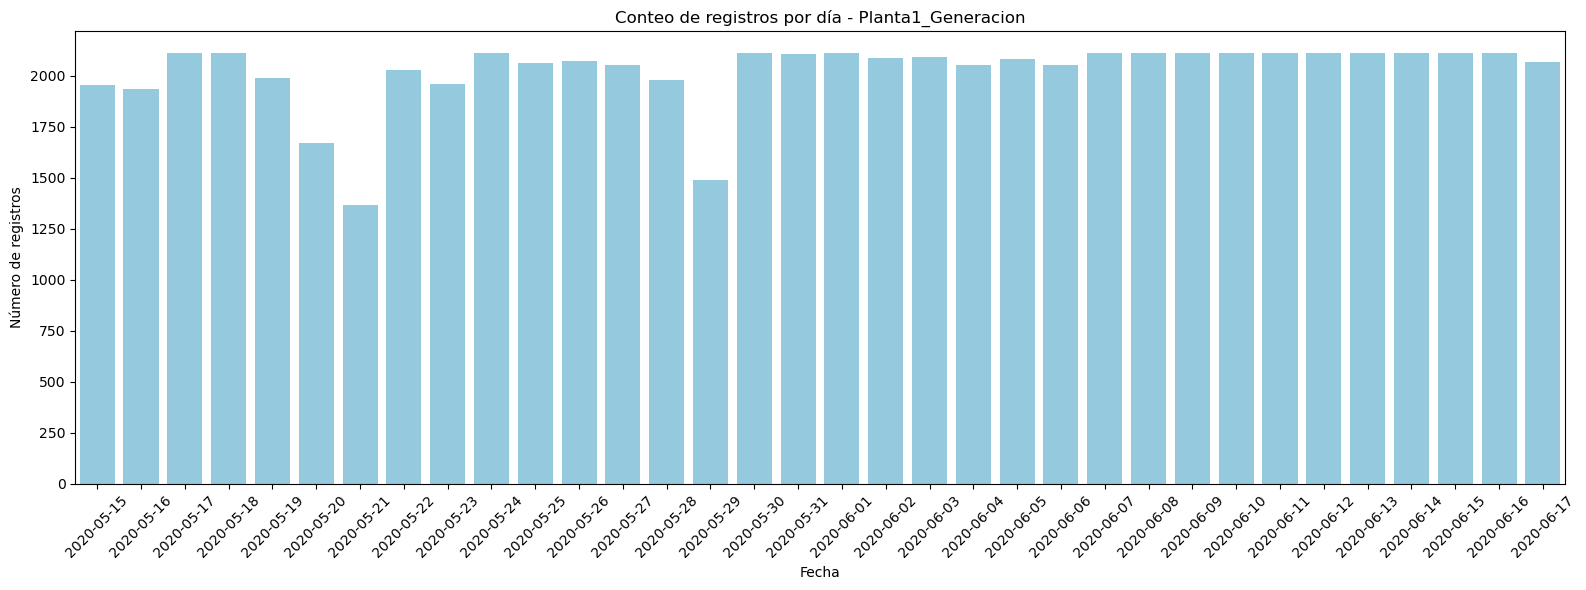

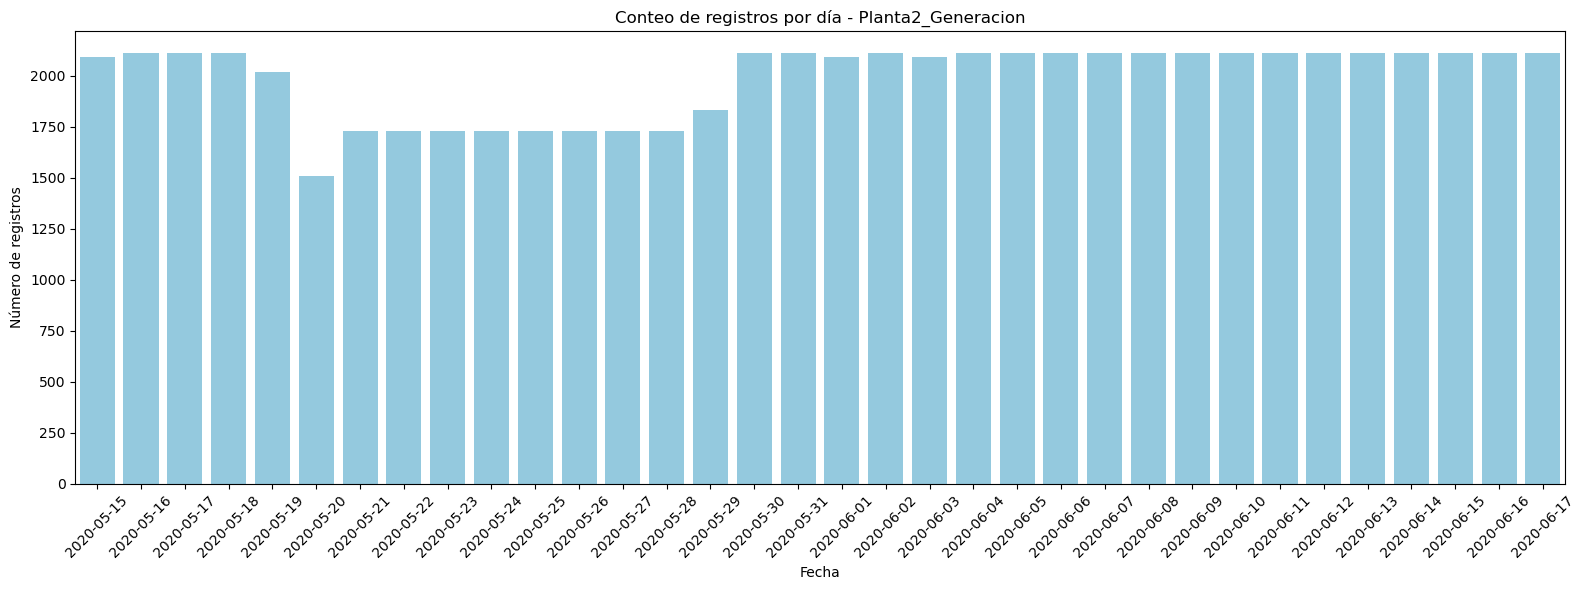

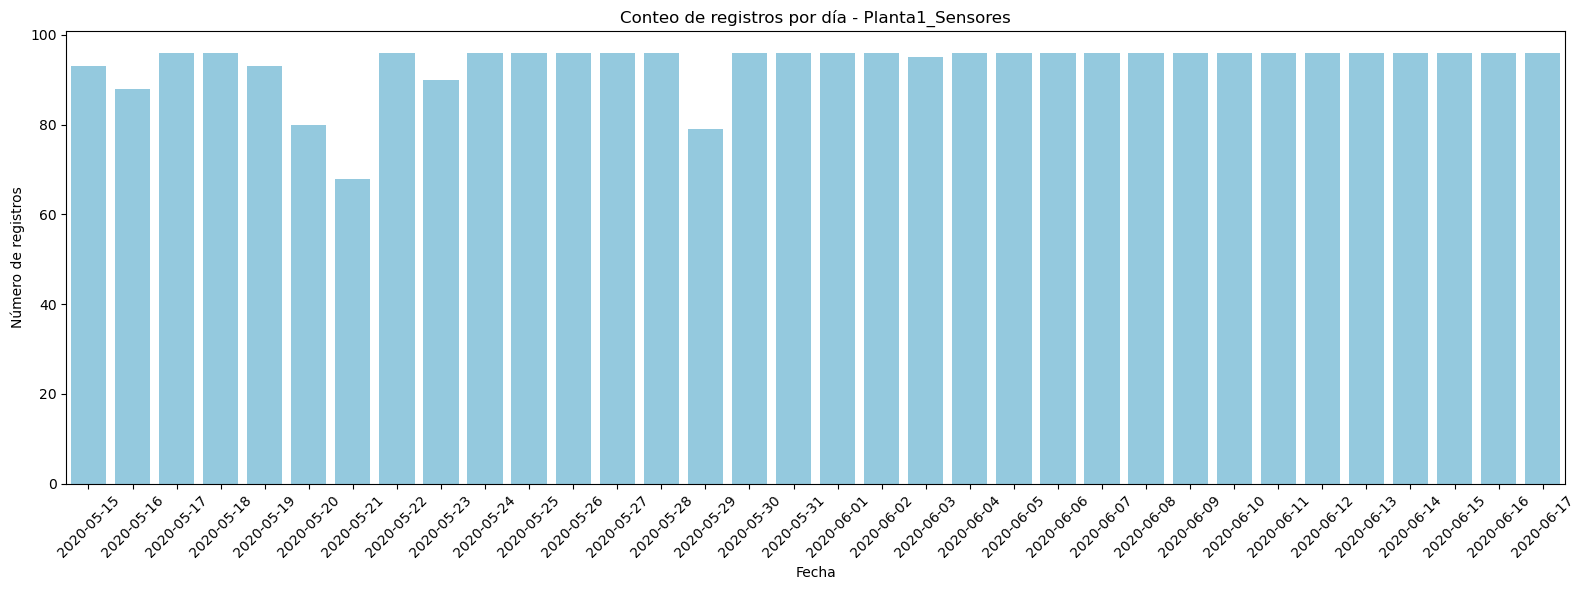

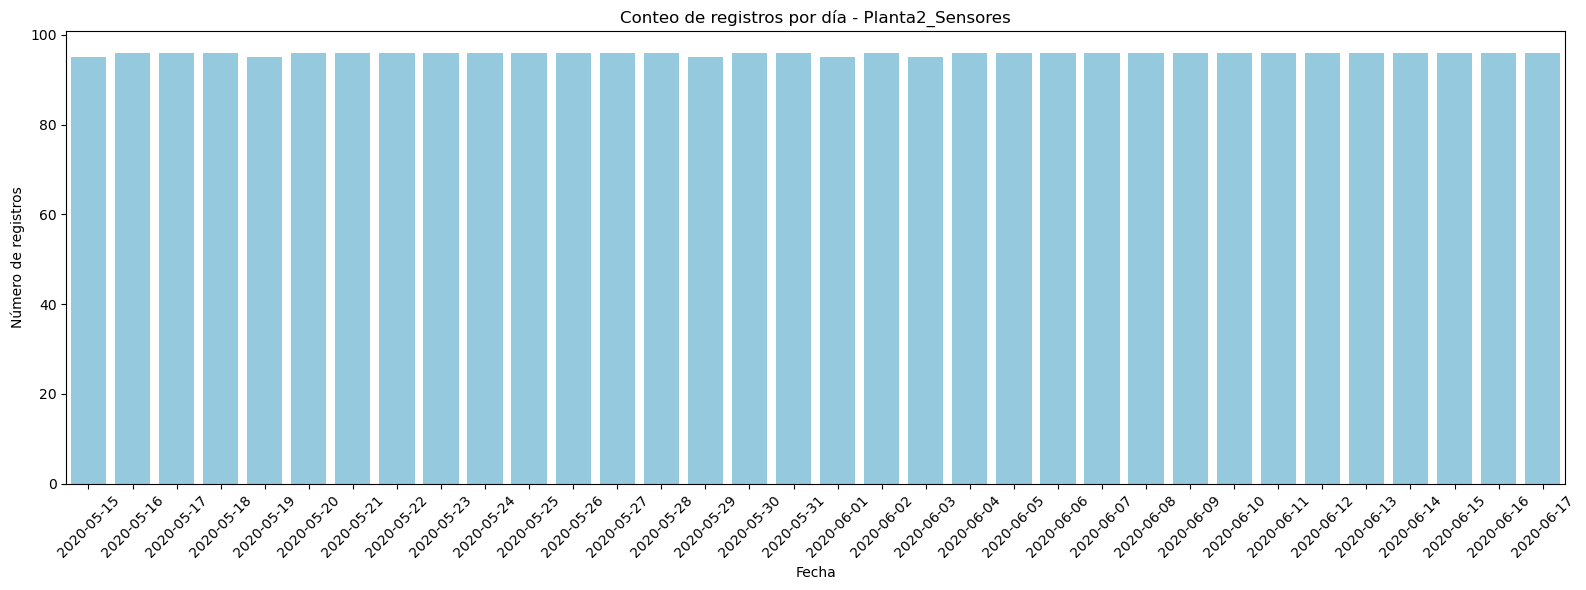

In [39]:
# Gráfico de barras de un groupby por fecha y conteo de registros, sin referencia de tramos esperados
for nombre, df in datasets.items():
    df_temp = df.copy()
    df_temp['fecha'] = df_temp['fecha_hora'].dt.date
    conteo_por_dia = df_temp.groupby('fecha').size()
    
    plt.figure(figsize=(16,6))
    sns.barplot(x=conteo_por_dia.index, y=conteo_por_dia.values, color='skyblue')
    plt.title(f'Conteo de registros por día - {nombre}')
    plt.xlabel('Fecha')
    plt.ylabel('Número de registros')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


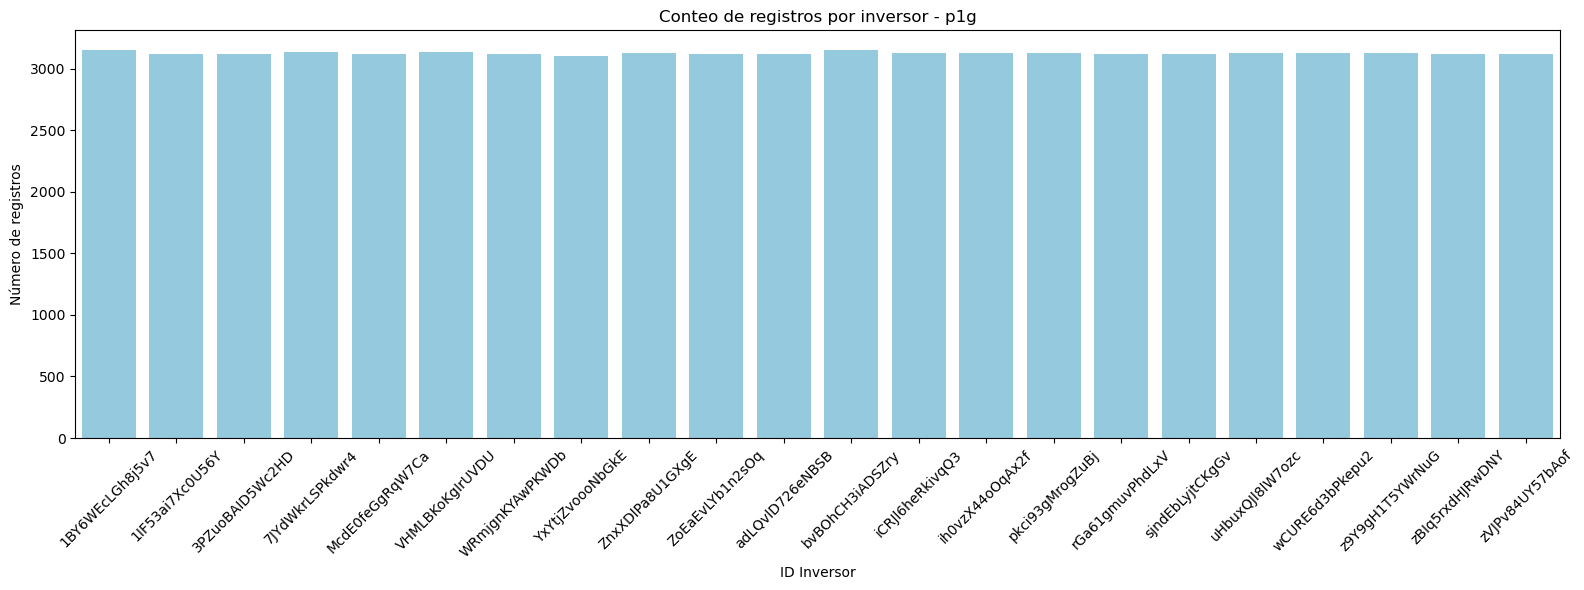

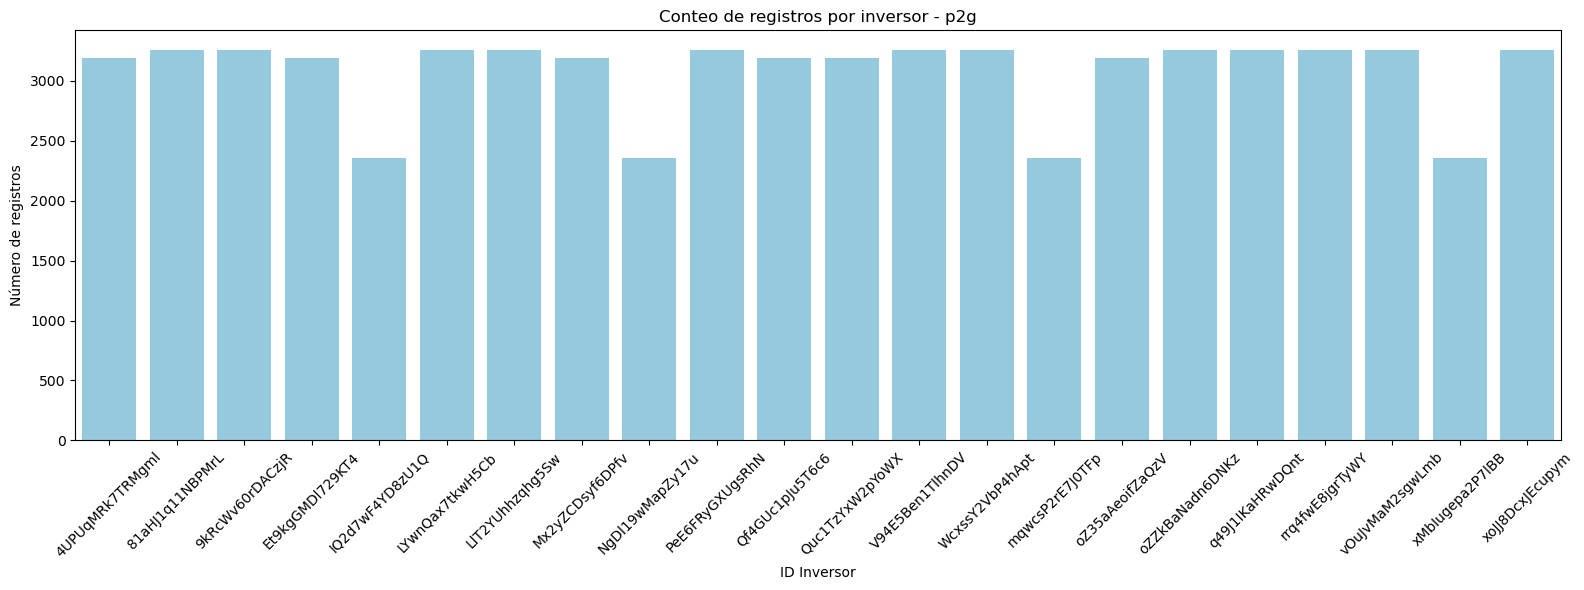

In [40]:
for nombre, df in zip(['p1g', 'p2g'], [p1g, p2g]):
    conteo_por_inversor = df.groupby('id_inversor').size()
    plt.figure(figsize=(16,6))
    sns.barplot(x=conteo_por_inversor.index, y=conteo_por_inversor.values, color='skyblue')
    plt.title(f'Conteo de registros por inversor - {nombre}')
    plt.xlabel('ID Inversor')
    plt.ylabel('Número de registros')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


**INSIGHT 3:**

En análisis de registros por inverter muestra que:

* En la planta 1 los inverters tienen nivel similar de registros lo cual sugiere que el problema puede estar en los tramos horarios perdidos y no en ningún inverter en concreto

* En la planta 2 sí que parece que existen 4 inverters concretos que tienen un nivel de pérdida de datos superior al resto

Continuar profundizando en este análisis y resultados en la fase de EDA

In [41]:
gener = pd.concat([p1g,p2g], axis = 'index')

In [44]:
sensor = pd.concat([p1s,p2s], axis = 'index')

In [49]:
df = pd.merge(gener, sensor, on=['fecha_hora', 'id_planta'], how='left')

In [52]:
df[df.id_sensor_meteorologico.isna()]

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
38544,2020-06-03 14:00:00,p1,1IF53ai7Xc0U56Y,700.3,685.8,5601.0,6330385.0,NaN,NaN,NaN,NaN
38545,2020-06-03 14:00:00,p1,adLQvlD726eNBSB,720.4,705.4,5685.0,6419961.0,NaN,NaN,NaN,NaN
38546,2020-06-03 14:00:00,p1,wCURE6d3bPkepu2,754.5,738.7,5579.0,6928448.0,NaN,NaN,NaN,NaN
38547,2020-06-03 14:00:00,p1,z9Y9gH1T5YWrNuG,794.6,777.8,5541.0,7152815.0,NaN,NaN,NaN,NaN


In [53]:
df = df.dropna()

In [55]:
df.to_pickle(Path(os.getcwd()).parent / 'datos' / 'intermedios' / 'tablon_analitico.pkl')